In [1]:
import os
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, BatchNormalization, Conv2D, MaxPooling2D
from tensorflow.keras import models, layers
from tensorflow.keras.optimizers import Adam

In [5]:
dataset_path = '/kaggle/input/datasets/alwaysashif/petrol-diesel-datafile-melspectrogram/Extract Cars Sound'

In [6]:
total_image = 0

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.lower().endswith(('jpg', 'jpeg', 'png', 'bmp')):
            total_image += 1
print("Total Image :", total_image)

Total Image : 320


In [7]:
classes = [
    folder
    for folder in os.listdir(dataset_path)
    if os.path.isdir(os.path.join(dataset_path, folder))
    
]

print("Number of Classes : ", len(classes))
print("Classes are : ", classes)

Number of Classes :  2
Classes are :  ['Diesel Motor Sound', 'Petrol Motor Sound']


In [8]:
for cls in classes:
    path = os.path.join(dataset_path, cls)
    count = len([
        file
        for file in os.listdir(path)
        if file.lower().endswith(('jpg', 'jpeg', 'png'))
        
    ])
    print(cls ," : " , count)

Diesel Motor Sound  :  183
Petrol Motor Sound  :  137


In [9]:
from PIL import Image
sizes = set()

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.lower().endswith(('jpg', 'jpeg', 'png')):
            path = os.path.join(root, file)
            img = Image.open(path)
            sizes.add(img.size)
print("different image sizes : ", len(sizes))
print("Sizes :", sizes)

different image sizes :  1
Sizes : {(232, 231)}


In [10]:
IMAGE_SIZE = 256
BATCH_SIZE = 16

In [11]:
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    shuffle = True,
    image_size = (IMAGE_SIZE, IMAGE_SIZE),
    batch_size = BATCH_SIZE
)

Found 320 files belonging to 2 classes.


I0000 00:00:1790197178.931053      84 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1790197178.937282      84 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [13]:
class_names = dataset.class_names
print(class_names)

['Diesel Motor Sound', 'Petrol Motor Sound']


In [14]:
classes_name = dataset.class_names
print(classes_name)

['Diesel Motor Sound', 'Petrol Motor Sound']


In [15]:
for images, labels in dataset:
    print(images.shape)
    print(labels.shape)
    break 

print(labels)

(16, 256, 256, 3)
(16,)
tf.Tensor([0 0 1 0 0 0 1 1 1 0 1 0 0 1 0 0], shape=(16,), dtype=int32)


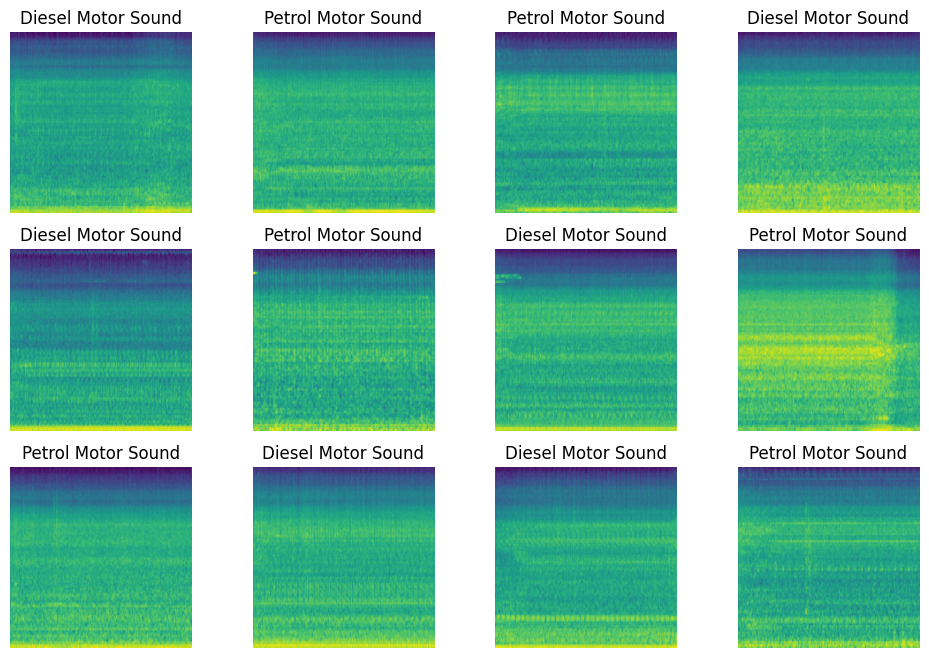

In [16]:
for image_batch, label_batch in dataset.take(1):
    plt.figure(figsize= (12,8))
    for i in range(12):
        ax = plt.subplot(3,4, i+1)
        plt.imshow(image_batch[i].numpy().astype('uint8'))
        plt.title(classes_name[label_batch[i]])
        plt.axis("off")

In [17]:
train_size = 0.80
val_size = 0.10
test_size = 0.10

In [18]:
print(len(dataset)*train_size)
print(len(dataset)*test_size)
print(len(dataset)*val_size)

16.0
2.0
2.0


In [19]:
train_ds = dataset.take(16)
test_ds = dataset.skip(16)
val_ds = test_ds.take(2)
test_ds = test_ds.skip(2)

In [20]:
print("Train dataset batch :", len(train_ds))
print("Validation dataset batch :", len(val_ds))
print("Test dataset batch :", len(test_ds))

Train dataset batch : 16
Validation dataset batch : 2
Test dataset batch : 2


In [21]:
resize_and_rescale = tf.keras.Sequential([
  layers.Resizing(IMAGE_SIZE, IMAGE_SIZE),
  layers.Rescaling(1./255),
])

# Build CNN Model

In [22]:
model = Sequential()
model.add(layers.Input(shape = (256,256,3)))
model.add(resize_and_rescale)

model.add(Conv2D(32,(3,3), activation = 'relu'))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64,(3,3),activation = 'relu'))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64,(3,3),activation = 'relu'))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(96,(3,3),activation = 'relu'))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(96,(3,3),activation = 'relu'))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(128,(3,3),activation = 'relu'))
model.add(MaxPooling2D((2,2)))


model.add(Flatten())

model.add(Dense(16, activation='relu'))
#model.add(Dropout(0.5))

model.add(Dense(1, activation='sigmoid'))

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 96)     │        55,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 96)     │        83,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 6, 6, 96)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 128)      │       110,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │         8,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 313,697 (1.20 MB)

 Trainable params: 313,697 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train Model

In [24]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=40
)

Epoch 1/40


2026-09-23 21:01:15.380935: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-23 21:01:15.678347: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


 3/16 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.4965 - loss: 0.6936 

I0000 00:00:1790197278.622189     132 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


16/16 ━━━━━━━━━━━━━━━━━━━━ 12s 144ms/step - accuracy: 0.5195 - loss: 0.6920 - val_accuracy: 0.5625 - val_loss: 0.6897
Epoch 2/40
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - accuracy: 0.5664 - loss: 0.6851 - val_accuracy: 0.6562 - val_loss: 0.6615
Epoch 3/40
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 0.5898 - loss: 0.6710 - val_accuracy: 0.5938 - val_loss: 0.6564
Epoch 4/40
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 0.5430 - loss: 0.6861 - val_accuracy: 0.3750 - val_loss: 0.7136
Epoch 5/40
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 0.5742 - loss: 0.6712 - val_accuracy: 0.5312 - val_loss: 0.6972
Epoch 6/40
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 0.5781 - loss: 0.6636 - val_accuracy: 0.6562 - val_loss: 0.6251
Epoch 7/40
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 0.6094 - loss: 0.6609 - val_accuracy: 0.6250 - val_loss: 0.6822
Epoch 8/40
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 0.6133 - loss: 0.6478 - val_accuracy: 0.6875 - val_loss: 

# Accuracy Score for New Unseen Data

In [25]:
loss, accuracy = model.evaluate(test_ds)
print("Test Accuracy :", accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.8438 - loss: 0.3582 
Test Accuracy : 0.84375


In [54]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

true = []
pred = []

for images, labels in test_ds:
    
    predictions = model.predict(images, verbose=0)
    
    predictions = (predictions > 0.5).astype(int).flatten()
    
    true.extend(labels.numpy())
    pred.extend(predictions)

true = np.array(true)
pred = np.array(pred)

cm = confusion_matrix(true, pred)

print(cm)

[[21  0]
 [ 2  9]]


In [55]:
print("True shape:", true.shape)
print("Pred shape:", pred.shape)

print("True:", true[:20])
print("Pred:", pred[:20])

True shape: (32,)
Pred shape: (32,)
True: [0 1 0 0 0 1 1 0 0 0 0 0 0 1 1 0 0 0 0 0]
Pred: [0 1 0 0 0 1 1 0 0 0 0 0 0 1 0 0 0 0 0 0]


In [62]:
print(classification_report(
    true,
    pred
))

              precision    recall  f1-score   support

           0       0.91      1.00      0.95        21
           1       1.00      0.82      0.90        11

    accuracy                           0.94        32
   macro avg       0.96      0.91      0.93        32
weighted avg       0.94      0.94      0.94        32



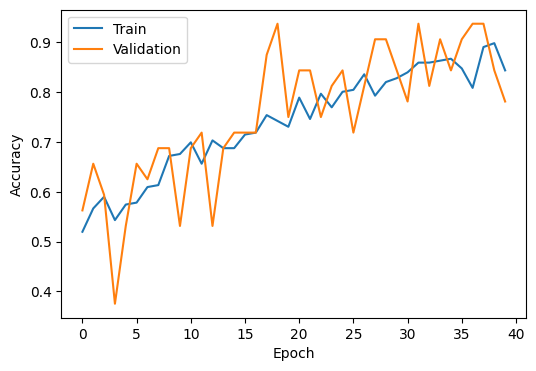

In [26]:
plt.figure(figsize=(6,4))
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

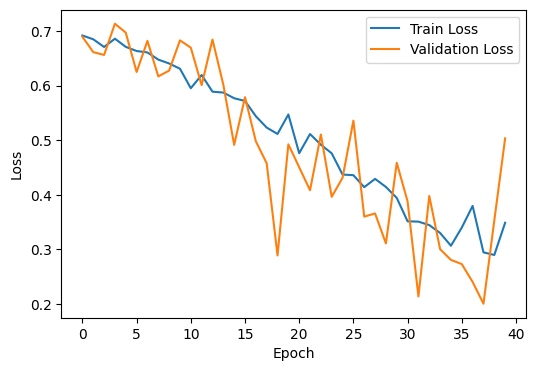

In [27]:
plt.figure(figsize=(6,4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [64]:
new_test_data, new_label = next(iter(test_ds))
image = new_test_data[0]
actual = int(new_label[0])

prediction = model.predict(np.expand_dims(image, axis=0), verbose=0)
predicted = int(prediction[0][0]>0.5)

print("Actual Label :", class_names[actual])
print("Predicted Label :", class_names[predicted])

Actual Label : Diesel Motor Sound
Predicted Label : Diesel Motor Sound
